In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/weather_delhi.csv")

df.head()

,time,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_gusts_10m
0,2025-01-01 00:00:00,8.3,100,7.4,0.0,99,2.8,4.7
1,2025-01-01 01:00:00,8.0,100,7.0,0.0,100,2.9,5.4
2,2025-01-01 02:00:00,7.8,100,6.5,0.0,100,4.7,10.1
3,2025-01-01 03:00:00,8.0,99,6.5,0.0,100,5.8,12.6
4,2025-01-01 04:00:00,7.7,98,6.1,0.0,100,6.3,13.0


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8760
Columns: 8


In [4]:
df.columns.tolist()

['time',
 'temperature_2m',
 'relative_humidity_2m',
 'apparent_temperature',
 'precipitation',
 'cloud_cover',
 'wind_speed_10m',
 'wind_gusts_10m']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  8760 non-null   str    
 1   temperature_2m        8760 non-null   float64
 2   relative_humidity_2m  8760 non-null   int64  
 3   apparent_temperature  8760 non-null   float64
 4   precipitation         8760 non-null   float64
 5   cloud_cover           8760 non-null   int64  
 6   wind_speed_10m        8760 non-null   float64
 7   wind_gusts_10m        8760 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 547.6 KB


In [6]:
missing = df.isnull().sum()

print(missing)

time                    0
temperature_2m          0
relative_humidity_2m    0
apparent_temperature    0
precipitation           0
cloud_cover             0
wind_speed_10m          0
wind_gusts_10m          0
dtype: int64


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
df.describe()

,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_gusts_10m
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,25.275342,60.617922,26.892831,0.081735,34.272717,6.640685,17.578573
std,7.463091,23.657999,9.271445,0.530325,41.845766,3.417600,8.730237
min,7.700000,4.000000,5.800000,0.000000,0.000000,0.000000,0.700000
25%,20.000000,42.000000,19.100000,0.000000,0.000000,4.200000,11.200000
50%,26.600000,63.000000,28.900000,0.000000,7.000000,6.100000,16.200000
75%,30.500000,80.000000,34.500000,0.000000,88.000000,8.600000,23.000000
max,43.700000,100.000000,46.600000,12.000000,100.000000,25.800000,71.600000


In [9]:
df["time"] = pd.to_datetime(df["time"])

In [10]:
print("Start:", df["time"].min())
print("End:", df["time"].max())

Start: 2025-01-01 00:00:00
End: 2025-12-31 23:00:00


In [11]:
print("Unique timestamps:", df["time"].nunique())
print("Total rows:", len(df))

Unique timestamps: 8760
Total rows: 8760


In [12]:
time_diff = df["time"].sort_values().diff()

print(time_diff.value_counts().head())

time
0 days 01:00:00    8759
Name: count, dtype: int64


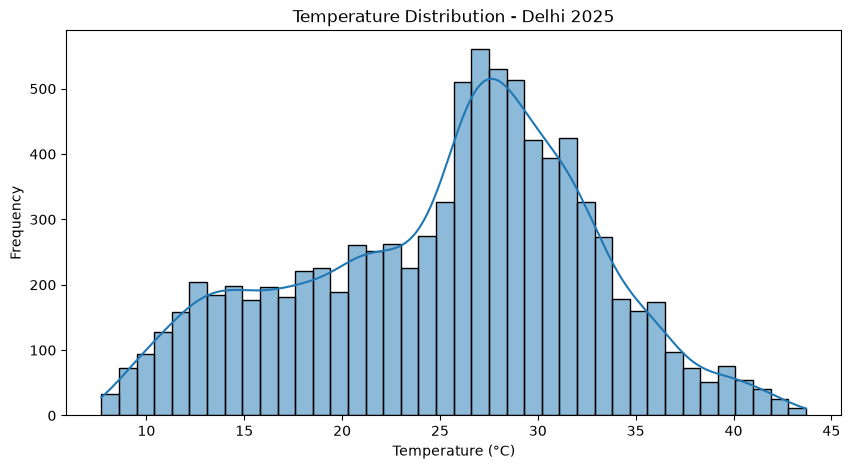

In [13]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["temperature_2m"],
    bins=40,
    kde=True
)

plt.title("Temperature Distribution - Delhi 2025")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

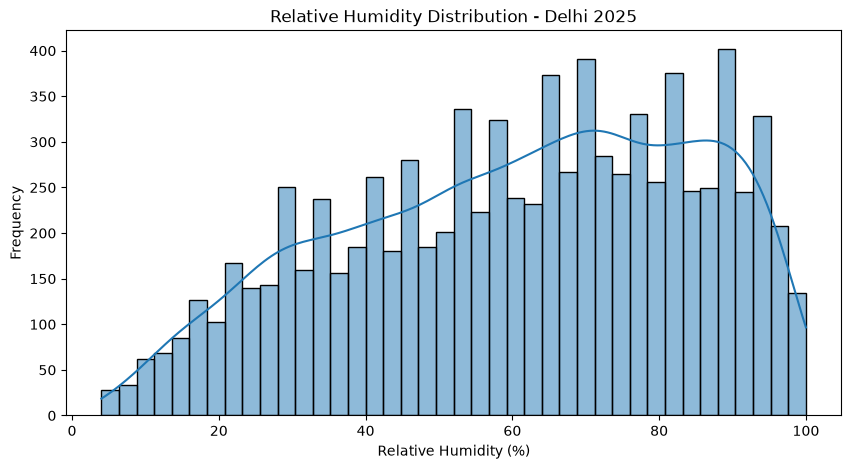

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["relative_humidity_2m"],
    bins=40,
    kde=True
)

plt.title("Relative Humidity Distribution - Delhi 2025")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Frequency")

plt.show()

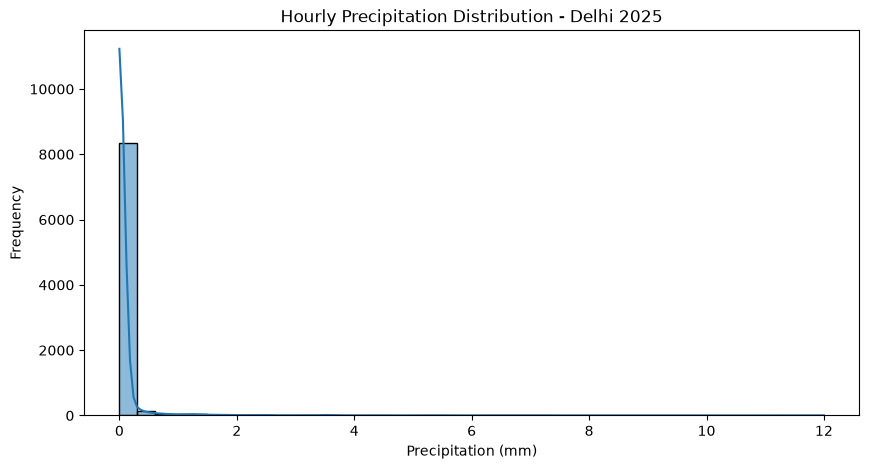

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["precipitation"],
    bins=40,
    kde=True
)

plt.title("Hourly Precipitation Distribution - Delhi 2025")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")

plt.show()

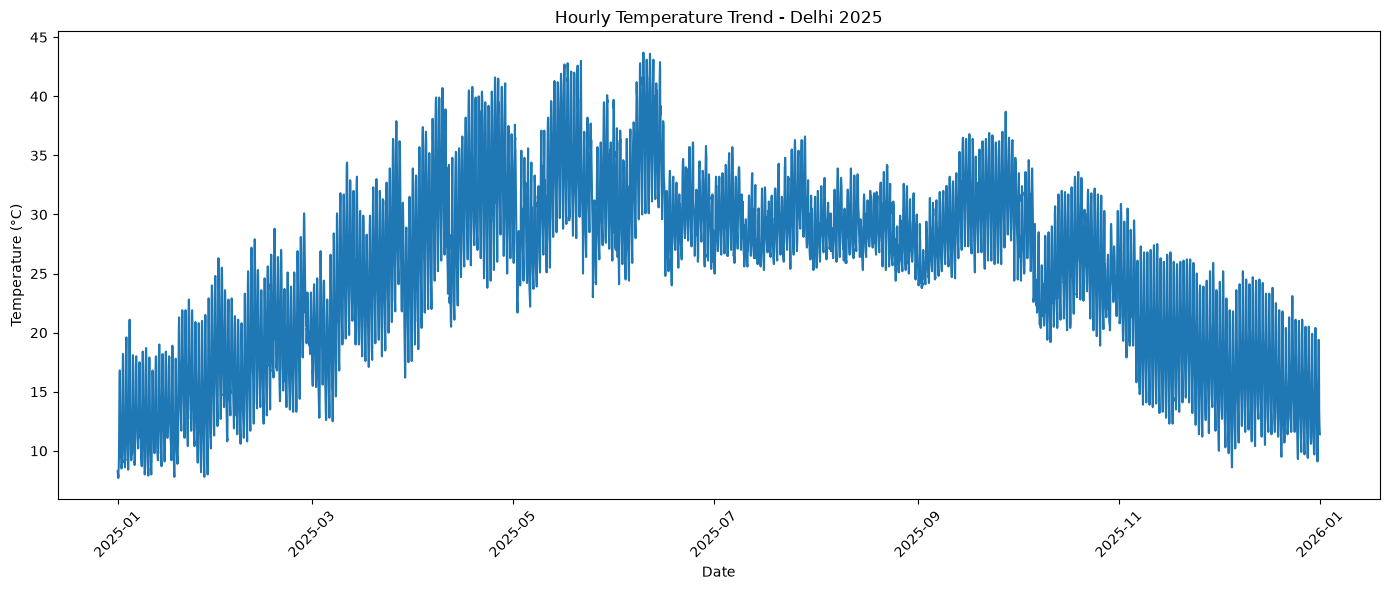

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["time"],
    df["temperature_2m"]
)

plt.title("Hourly Temperature Trend - Delhi 2025")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

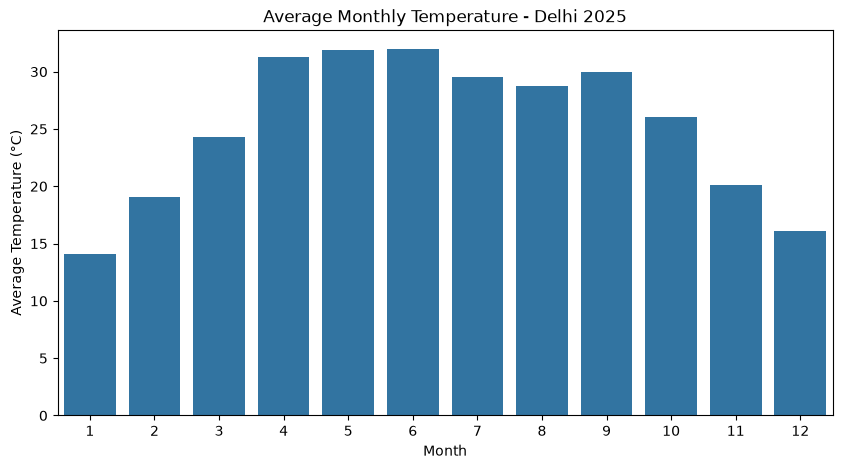

In [17]:
df["month"] = df["time"].dt.month

monthly_temp = (
    df.groupby("month")["temperature_2m"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=monthly_temp,
    x="month",
    y="temperature_2m"
)

plt.title("Average Monthly Temperature - Delhi 2025")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")

plt.show()

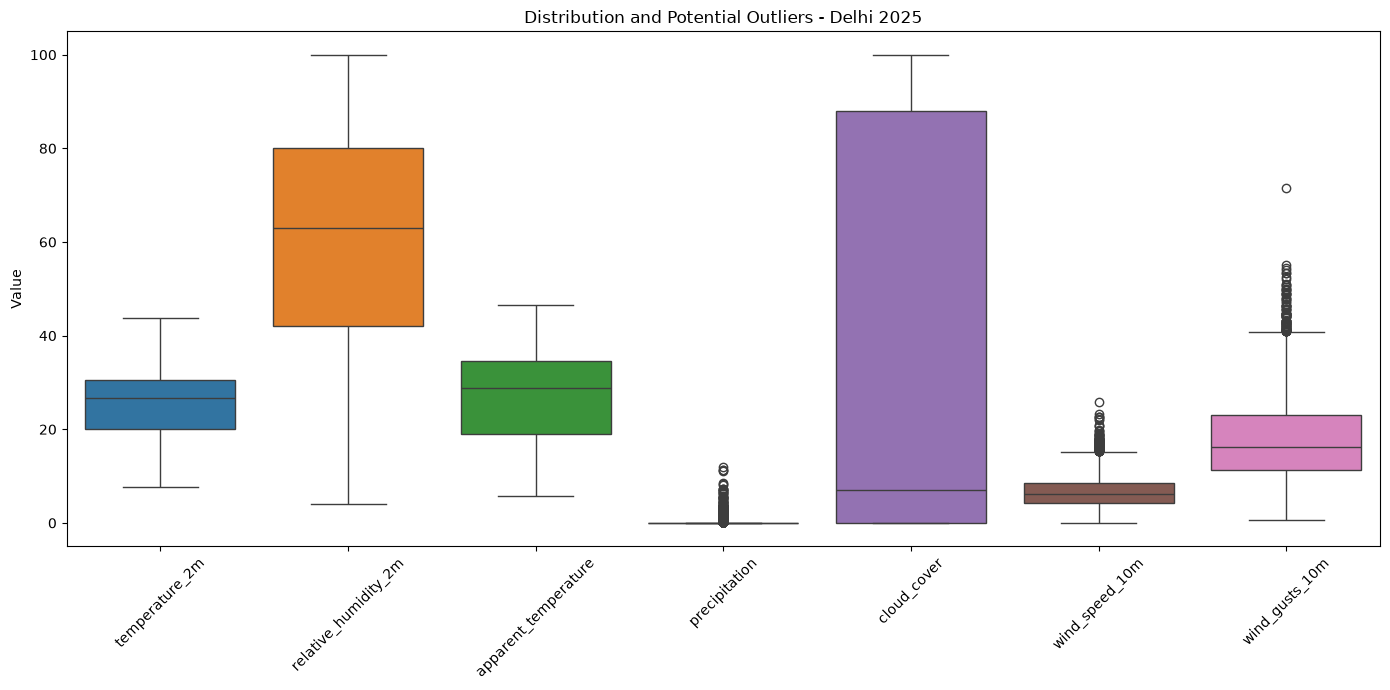

In [18]:
numeric_columns = [
    "temperature_2m",
    "relative_humidity_2m",
    "apparent_temperature",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "wind_gusts_10m"
]

plt.figure(figsize=(14, 7))

sns.boxplot(data=df[numeric_columns])

plt.title("Distribution and Potential Outliers - Delhi 2025")
plt.xticks(rotation=45)
plt.ylabel("Value")

plt.tight_layout()
plt.show()

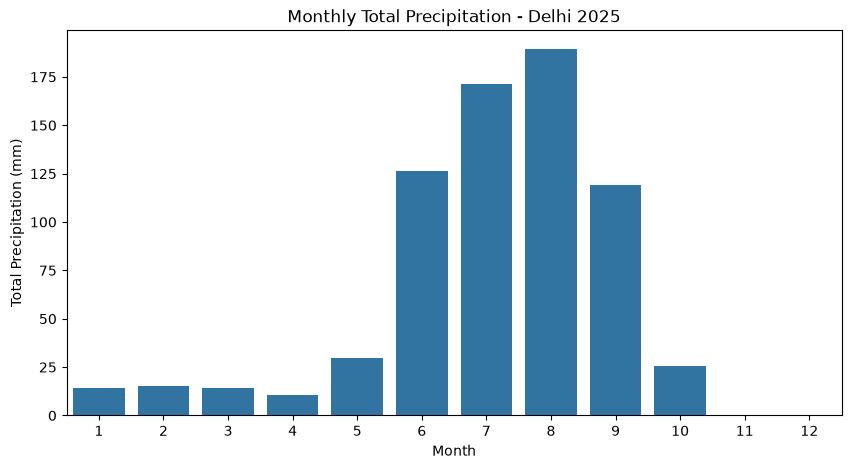

In [19]:
monthly_rainfall = (
    df.groupby(df["time"].dt.month)["precipitation"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=monthly_rainfall,
    x="time",
    y="precipitation"
)

plt.title("Monthly Total Precipitation - Delhi 2025")
plt.xlabel("Month")
plt.ylabel("Total Precipitation (mm)")

plt.show()

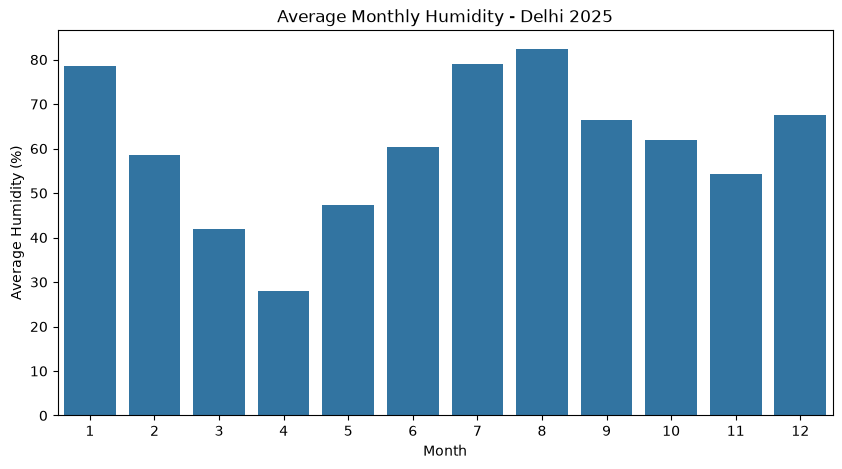

In [20]:
monthly_humidity = (
    df.groupby(df["time"].dt.month)["relative_humidity_2m"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=monthly_humidity,
    x="time",
    y="relative_humidity_2m"
)

plt.title("Average Monthly Humidity - Delhi 2025")
plt.xlabel("Month")
plt.ylabel("Average Humidity (%)")

plt.show()

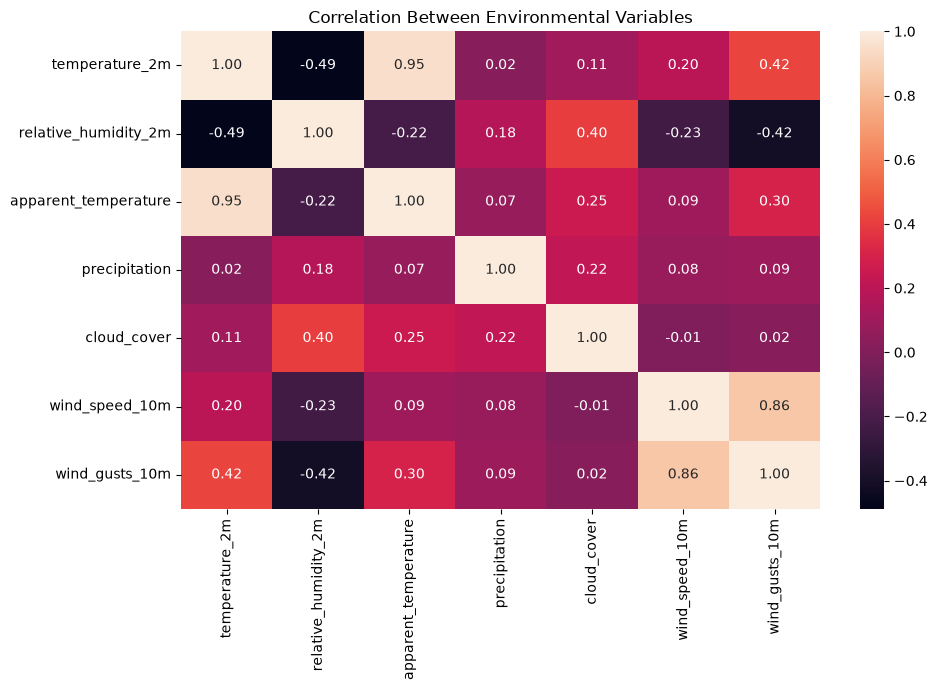

In [21]:
plt.figure(figsize=(10, 7))

correlation = df[numeric_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Environmental Variables")

plt.tight_layout()
plt.show()

## Key Findings

- The dataset contains **8,760 hourly observations** covering the complete period from **January 1, 2025 to December 31, 2025**, providing continuous year-long environmental data for Delhi.

- The dataset contains **no missing values and no duplicate records**, indicating good data completeness and consistency. All 8,760 timestamps are unique and occur at **one-hour intervals**.

- Temperature shows a clear **seasonal pattern** throughout the year. The average monthly temperature rises from approximately **14°C in January** to above **30°C during April–June**, before declining toward the end of the year.

- The recorded temperature ranges from **7.7°C to 43.7°C**, while apparent temperature reaches **46.6°C**. These high values represent important environmental extremes and should not automatically be removed as statistical outliers because extreme conditions are relevant to climate-impact analysis.

- Relative humidity varies substantially throughout the year, with lower levels around **April (~28%)** and higher levels during the **monsoon period, particularly July–August (~78–82%)**.

- Precipitation is highly concentrated during the **monsoon season**. Monthly rainfall increases sharply from **June through September**, with **August recording the highest monthly precipitation** in the dataset.

- The precipitation distribution is strongly **right-skewed**, with most hourly observations having **0 mm rainfall** and relatively few observations containing higher rainfall amounts. The maximum recorded hourly precipitation is **12 mm**.

- The correlation analysis shows a **very strong positive relationship between temperature and apparent temperature (0.95)**. Wind speed and wind gusts also have a strong positive correlation of approximately **0.86**.

- Temperature and relative humidity show a **moderate negative correlation (-0.49)**, while temperature and wind speed have a relatively weak positive correlation (**0.20**).

- Overall, the dataset is **structurally clean and suitable for further processing**. The EDA reveals clear seasonal patterns, rainfall concentration during the monsoon period, substantial temperature variation, and meaningful relationships between environmental variables.

### EDA Conclusion

The exploratory analysis indicates that the dataset has good quality and contains meaningful seasonal and environmental patterns. Since extreme temperature and rainfall events are important for assessing climate impact, legitimate extreme observations will be **preserved rather than removed automatically**. Further processing will focus on data validation, feature engineering, and preparation of the dataset for climate-impact analysis and forecasting.